In [ ]:
import json
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["axes.linewidth"] = 0.8
matplotlib.rcParams["xtick.major.width"] = 0.8
matplotlib.rcParams["ytick.major.width"] = 0.8

In [ ]:
METRICS_ROOT = Path(
    "/ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_rpe/metrics"
)

OUT_DIR = METRICS_ROOT / "_strategy_scatterplots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS_ORDER = ["hvg", "scvi", "sccello", "scimilarity", "scgpt"]

METRICS_TO_PLOT = [
    "forward_effect_mae",
    "forward_effect_mse",
    "inverse_accuracy",
    "inverse_macro_f1",
    "inverse_macro_precision",
    "inverse_macro_recall",
]

# Strategy display labels and colors.
# Base strategy names are parsed from variant_slug values such as
# S5_SEACell_OT_sampled_average__nmc_350__topk_05__seed_000.
STRATEGY_PLOT_LABELS = {
    "S0_naive_mean_control_reference": "Naive\nmean\ncontrol",
    "S1_random_single_control": "Random\nsingle\ncontrol",
    "S2_random_average_controls": "Random\naverage\ncontrol",
    "S4_SEACell_balanced_random_sample": "Metacell\nbalanced\nrandom",
    "S3_SEACell_metacell_average": "Random\nmetacell\naverage",
    "S5_SEACell_OT_sampled_average": "Metacell OT\nsampled\naverage",
}

STRATEGY_BASE_COLORS = {
    "S0_naive_mean_control_reference": "#D0E0EF",
    "S1_random_single_control": "#6E8FB2",
    "S2_random_average_controls": "#7DA494",
    "S3_SEACell_metacell_average": "#E5A79A",
    "S4_SEACell_balanced_random_sample": "#EAB67A",
    "S5_SEACell_OT_sampled_average": "#9F8DB8",
}

# Special colors for S5 OT variants. Key format = "nmc&topk", e.g. nmc_350 + topk_05 -> "350&5".
S5_VARIANT_COLORS = {
    "200&5": "#D49AB5",
    "350&5": "#7D5284",
    "500&5": "#B66699",
}

# Preferred order in legend and within each model group.
# Exact variant slugs are used here to preserve deterministic plotting order.
# RPE
STRATEGY_ORDER = [
    "S0_naive_mean_control_reference",
    "S1_random_single_control__seed_000",
    "S2_random_average_controls__k_100__seed_000",
    "S3_SEACell_metacell_average__nmc_350__k_10__seed_000",
    "S4_SEACell_balanced_random_sample__nmc_500__seed_000",
    "S5_SEACell_OT_sampled_average__nmc_350__topk_05__seed_000",
    "S5_SEACell_OT_sampled_average__nmc_500__topk_05__seed_000",
]
# K562
# STRATEGY_ORDER = [
#     "S0_naive_mean_control_reference",
#     "S1_random_single_control__seed_000",
#     "S2_random_average_controls__k_100__seed_000",
#     "S3_SEACell_metacell_average__nmc_100__k_03__seed_000",
#     "S4_SEACell_balanced_random_sample__nmc_100__seed_000",
#     "S5_SEACell_OT_sampled_average__nmc_350__topk_05__seed_000",
#     "S5_SEACell_OT_sampled_average__nmc_500__topk_05__seed_000",
# ]

# Scatter position settings.
# Set DODGE_WIDTH = 0.0 if you want all strategy points exactly at the same model x-position.
DODGE_WIDTH = 0.42
POINT_SIZE = 72
ALPHA = 0.9

SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True
DPI = 300
FIGSIZE = (10, 6)

print(f"[Info] METRICS_ROOT = {METRICS_ROOT}")
print(f"[Info] OUT_DIR = {OUT_DIR}")

[Info] METRICS_ROOT = /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics
[Info] OUT_DIR = /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots


In [ ]:
def load_one_run_result(json_path: Path) -> Dict:
    with open(json_path, "r") as f:
        record = json.load(f)

    # Infer model/variant from folder structure if missing.
    # Expected path: metrics/<model>/<variant_slug>/run_result.json
    try:
        variant_slug_from_path = json_path.parent.name
        model_from_path = json_path.parent.parent.name
    except Exception:
        variant_slug_from_path = ""
        model_from_path = ""

    record.setdefault("model", model_from_path)
    record.setdefault("variant_slug", variant_slug_from_path)
    record["run_result_path"] = str(json_path)
    return record


def scan_run_results(metrics_root: Path) -> pd.DataFrame:
    json_files = sorted(metrics_root.glob("*/*/run_result.json"))
    records = []
    for p in json_files:
        try:
            records.append(load_one_run_result(p))
        except Exception as e:
            print(f"[Warn] Failed reading {p}: {e}")

    if not records:
        raise FileNotFoundError(f"No run_result.json files found under: {metrics_root}")

    df = pd.DataFrame(records)

    # Keep only real model folders, excluding generated plot folders or non-model directories.
    if "model" in df.columns:
        df = df[df["model"].isin(MODELS_ORDER)].copy()

    # Make numeric metrics numeric.
    for metric in METRICS_TO_PLOT:
        if metric in df.columns:
            df[metric] = pd.to_numeric(df[metric], errors="coerce")

    # Save full scan.
    full_scan_path = OUT_DIR / "run_result_scan_all.csv"
    df.to_csv(full_scan_path, index=False)
    print(f"[Scan] Saved full scan: {full_scan_path}")
    print(f"[Scan] Loaded {len(df)} run_result records.")

    return df


results_df = scan_run_results(METRICS_ROOT)
display(results_df.head())

[Scan] Saved full scan: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/run_result_scan_all.csv
[Scan] Loaded 30 run_result records.


,run_id,model,variant,variant_slug,target_space,pseudo_embedding_dim,perturbation_embedding_dim,forward_input_dim,forward_output_dim,inverse_input_dim,n_perturbation_classes,hidden_dims,n_training_cells_total,status,error,embedding_path,effect_path,forward_checkpoint,inverse_checkpoint,forward_best_epoch,forward_best_val_mse,inverse_best_epoch,inverse_best_val_ce,forward_effect_mse,forward_effect_mae,forward_effect_rmse,forward_effect_cosine,inverse_accuracy,inverse_macro_f1,inverse_macro_precision,inverse_macro_recall,run_result_path
0,hvg__S1_random_single_control__seed_000,hvg,S1_random_single_control/seed_000,S1_random_single_control__seed_000,expression,50,128,178,3000,3000,2057,"[256, 256, 128]",299694,done,,/ibex/project/c2366/Perturb_data/Replogle_k562...,/tmp/embedding_mlp_runtime_cache_3607249/expre...,,,45,0.386661,4,6.332977,0.386576,0.491233,0.621752,0.226612,0.068847,0.021835,0.024018,0.032128,/ibex/user/chenj0i/Perturbation/SEACells/Junfa...
1,hvg__S2_random_average_controls__k_100__seed_000,hvg,S2_random_average_controls/k_100/seed_000,S2_random_average_controls__k_100__seed_000,expression,50,128,178,3000,3000,2057,"[256, 256, 128]",299694,done,,/ibex/project/c2366/Perturb_data/Replogle_k562...,/tmp/embedding_mlp_runtime_cache_3607249/expre...,,,17,0.213385,4,5.951390,0.213527,0.380760,0.462090,0.098302,0.099188,0.042172,0.046198,0.055227,/ibex/user/chenj0i/Perturbation/SEACells/Junfa...
2,hvg__S3_SEACell_metacell_average__nmc_100__k_0...,hvg,S3_SEACell_metacell_average/nmc_100/k_03/seed_000,S3_SEACell_metacell_average__nmc_100__k_03__se...,expression,50,128,178,3000,3000,2057,"[256, 256, 128]",299694,done,,/ibex/project/c2366/Perturb_data/Replogle_k562...,/tmp/embedding_mlp_runtime_cache_3607249/expre...,,,21,0.212399,4,5.993978,0.212532,0.380085,0.461012,0.193068,0.098009,0.040623,0.043196,0.054155,/ibex/user/chenj0i/Perturbation/SEACells/Junfa...
3,hvg__S4_SEACell_balanced_random_sample__nmc_10...,hvg,S4_SEACell_balanced_random_sample/nmc_100/seed...,S4_SEACell_balanced_random_sample__nmc_100__se...,expression,50,128,178,3000,3000,2057,"[256, 256, 128]",299694,done,,/ibex/project/c2366/Perturb_data/Replogle_k562...,/tmp/embedding_mlp_runtime_cache_3607249/expre...,,,44,0.382716,4,6.343857,0.382678,0.488785,0.618610,0.253773,0.068090,0.021163,0.022146,0.032540,/ibex/user/chenj0i/Perturbation/SEACells/Junfa...
4,hvg__S5_SEACell_OT_sampled_average__nmc_350__t...,hvg,S5_SEACell_OT_sampled_average/nmc_350/topk_05/...,S5_SEACell_OT_sampled_average__nmc_350__topk_0...,expression,50,128,178,3000,3000,2057,"[256, 256, 128]",299694,done,,/ibex/project/c2366/Perturb_data/Replogle_k562...,/tmp/embedding_mlp_runtime_cache_3607249/expre...,,,42,0.204161,4,6.012392,0.204494,0.370939,0.452210,0.271846,0.096363,0.038869,0.042933,0.052128,/ibex/user/chenj0i/Perturbation/SEACells/Junfa...


In [ ]:
# ============================================================

METRIC_LABELS = {
    "forward_effect_mae": "Forward effect MAE",
    "forward_effect_mse": "Forward effect MSE",
    "inverse_accuracy": "Inverse accuracy",
    "inverse_macro_f1": "Inverse macro F1",
    "inverse_macro_precision": "Inverse macro precision",
    "inverse_macro_recall": "Inverse macro recall",
}

LOWER_IS_BETTER = {
    "forward_effect_mae": True,
    "forward_effect_mse": True,
    "inverse_accuracy": False,
    "inverse_macro_f1": False,
    "inverse_macro_precision": False,
    "inverse_macro_recall": False,
}


def get_strategy_base(variant_slug: str) -> str:
    """Return the base strategy name from a full variant slug."""
    variant_slug = str(variant_slug)
    known_bases = sorted(STRATEGY_PLOT_LABELS.keys(), key=len, reverse=True)
    for base in known_bases:
        if variant_slug == base or variant_slug.startswith(base + "__"):
            return base
    return variant_slug.split("__seed_")[0]


def get_s5_variant_key(variant_slug: str) -> str:
    """Return S5 variant key such as '350&5' from a slug, otherwise ''."""
    variant_slug = str(variant_slug)
    if not variant_slug.startswith("S5_SEACell_OT_sampled_average"):
        return ""
    parts = variant_slug.split("__")
    nmc = None
    topk = None
    for part in parts:
        if part.startswith("nmc_"):
            nmc = part.replace("nmc_", "")
        elif part.startswith("topk_"):
            raw = part.replace("topk_", "")
            try:
                topk = str(int(raw))
            except ValueError:
                topk = raw.lstrip("0") or raw
    if nmc is not None and topk is not None:
        return f"{nmc}&{topk}"
    return ""


def get_strategy_label(variant_slug: str) -> str:
    """Return legend label with user-provided line breaks; disambiguate S5 variants."""
    base = get_strategy_base(variant_slug)
    label = STRATEGY_PLOT_LABELS.get(base, str(variant_slug))
    s5_key = get_s5_variant_key(variant_slug)
    if s5_key:
        label = f"{label}\n({s5_key})"
    return label


def get_strategy_color(variant_slug: str) -> str:
    """Return user-provided color; use special colors for S5 nmc/topk variants."""
    base = get_strategy_base(variant_slug)
    s5_key = get_s5_variant_key(variant_slug)
    if base == "S5_SEACell_OT_sampled_average" and s5_key in S5_VARIANT_COLORS:
        return S5_VARIANT_COLORS[s5_key]
    return STRATEGY_BASE_COLORS.get(base, "#999999")


def get_strategy_color_map(strategy_order: List[str]) -> Dict[str, str]:
    return {s: get_strategy_color(s) for s in strategy_order}


def get_strategy_offsets(strategy_order: List[str], dodge_width: float = 0.42) -> Dict[str, float]:
    n = len(strategy_order)
    if n <= 1 or dodge_width == 0:
        return {s: 0.0 for s in strategy_order}
    offsets = np.linspace(-dodge_width / 2, dodge_width / 2, n)
    return {s: float(o) for s, o in zip(strategy_order, offsets)}


def plot_metric_scatter(
    df: pd.DataFrame,
    metric: str,
    out_dir: Path,
    models_order: List[str] = MODELS_ORDER,
    point_size: int = POINT_SIZE,
    dodge_width: float = DODGE_WIDTH,
):
    if metric not in df.columns:
        print(f"[Skip] metric not found: {metric}")
        return None

    mdf = df.dropna(subset=[metric]).copy()
    if mdf.empty:
        print(f"[Skip] no valid values for metric: {metric}")
        return None

    strategy_order = list(mdf["variant_slug"].cat.categories)
    strategy_order = [s for s in strategy_order if s in set(mdf["variant_slug"].astype(str))]
    color_map = get_strategy_color_map(strategy_order)
    offset_map = get_strategy_offsets(strategy_order, dodge_width=dodge_width)

    model_x = {m: i for i, m in enumerate(models_order)}

    fig, ax = plt.subplots(figsize=FIGSIZE)

    for strategy in strategy_order:
        sdf = mdf[mdf["variant_slug"].astype(str).eq(strategy)].copy()
        if sdf.empty:
            continue

        xs = []
        ys = []
        for _, row in sdf.iterrows():
            model = str(row["model"])
            if model not in model_x:
                continue
            xs.append(model_x[model] + offset_map[strategy])
            ys.append(float(row[metric]))

        if not xs:
            continue

        ax.scatter(
            xs,
            ys,
            s=point_size,
            alpha=ALPHA,
            label=STRATEGY_PLOT_LABELS.get(strategy, strategy),
            color=color_map[strategy],
            edgecolor="black",
            linewidth=0.4,
        )

    # Connect points belonging to the same strategy across models for easier visual tracking.
    for strategy in strategy_order:
        sdf = mdf[mdf["variant_slug"].astype(str).eq(strategy)].copy()
        sdf = sdf.sort_values("model")
        xs, ys = [], []
        for _, row in sdf.iterrows():
            model = str(row["model"])
            if model in model_x:
                xs.append(model_x[model] + offset_map[strategy])
                ys.append(float(row[metric]))
        if len(xs) >= 2:
            ax.plot(xs, ys, linewidth=0.8, alpha=0.35, color=color_map[strategy])

    ax.set_xticks(range(len(models_order)))
    ax.set_xticklabels(models_order, rotation=0)
    ax.set_xlabel("Embedding model")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    title_suffix = "lower is better" if LOWER_IS_BETTER.get(metric, False) else "higher is better"
    ax.set_title(f"{METRIC_LABELS.get(metric, metric)} by model and pseudo-control strategy ({title_suffix})")

    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Pseudo-control strategy",
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        borderaxespad=0,
        frameon=False,
        fontsize=8,
        title_fontsize=9,
    )

    fig.tight_layout()

    png_path = out_dir / f"{metric}_strategy_scatter.png"
    pdf_path = out_dir / f"{metric}_strategy_scatter.pdf"
    svg_path = out_dir / f"{metric}_strategy_scatter.svg"

    if SAVE_PNG:
        fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    if SAVE_PDF:
        fig.savefig(pdf_path, bbox_inches="tight")
    if SAVE_SVG:
        fig.savefig(svg_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"[Plot] Saved: {png_path if SAVE_PNG else ''}")
    if SAVE_PDF:
        print(f"[Plot] Saved: {pdf_path}")
    if SAVE_SVG:
        print(f"[Plot] Saved: {svg_path}")
    return png_path

In [ ]:
# ============================================================

def prepare_plot_df(results_df: pd.DataFrame) -> pd.DataFrame:
    df = results_df.copy()

    if "status" in df.columns:
        df = df[df["status"].astype(str).eq("done")].copy()

    required = ["model", "variant_slug"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    # Categorical ordering.
    df["model"] = pd.Categorical(df["model"], categories=MODELS_ORDER, ordered=True)

    observed_strategies = list(df["variant_slug"].dropna().astype(str).unique())
    strategy_order = [s for s in STRATEGY_ORDER if s in observed_strategies]
    strategy_order += [s for s in observed_strategies if s not in strategy_order]
    df["variant_slug"] = pd.Categorical(df["variant_slug"], categories=strategy_order, ordered=True)

    df["strategy_base"] = df["variant_slug"].astype(str).map(get_strategy_base)
    df["s5_variant_key"] = df["variant_slug"].astype(str).map(get_s5_variant_key)
    df["strategy_label"] = df["variant_slug"].astype(str).map(get_strategy_label)
    df["strategy_color"] = df["variant_slug"].astype(str).map(get_strategy_color)

    df = df.sort_values(["model", "variant_slug"]).reset_index(drop=True)
    return df


plot_df = prepare_plot_df(results_df)
plot_table_path = OUT_DIR / "plotting_table.csv"
plot_df.to_csv(plot_table_path, index=False)
print(f"[Table] Saved plotting table: {plot_table_path}")
display(plot_df[["model", "variant_slug", "strategy_base", "s5_variant_key", "strategy_label", "strategy_color"] + [m for m in METRICS_TO_PLOT if m in plot_df.columns]].head(20))

[Table] Saved plotting table: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/plotting_table.csv


,model,variant_slug,strategy_base,s5_variant_key,strategy_label,strategy_color,forward_effect_mae,forward_effect_mse,inverse_accuracy,inverse_macro_f1,inverse_macro_precision,inverse_macro_recall
0,hvg,S1_random_single_control__seed_000,S1_random_single_control,,Random\nsingle\ncontrol,#6E8FB2,0.491233,0.386576,0.068847,0.021835,0.024018,0.032128
1,hvg,S2_random_average_controls__k_100__seed_000,S2_random_average_controls,,Random\naverage\ncontrol,#7DA494,0.380760,0.213527,0.099188,0.042172,0.046198,0.055227
2,hvg,S3_SEACell_metacell_average__nmc_100__k_03__se...,S3_SEACell_metacell_average,,Random\nmetacell\naverage,#E5A79A,0.380085,0.212532,0.098009,0.040623,0.043196,0.054155
3,hvg,S4_SEACell_balanced_random_sample__nmc_100__se...,S4_SEACell_balanced_random_sample,,Metacell\nbalanced\nrandom,#EAB67A,0.488785,0.382678,0.068090,0.021163,0.022146,0.032540
4,hvg,S5_SEACell_OT_sampled_average__nmc_350__topk_0...,S5_SEACell_OT_sampled_average,350&5,Metacell OT\nsampled\naverage\n(350&5),#7D5284,0.370939,0.204494,0.096363,0.038869,0.042933,0.052128
5,hvg,S5_SEACell_OT_sampled_average__nmc_500__topk_0...,S5_SEACell_OT_sampled_average,500&5,Metacell OT\nsampled\naverage\n(500&5),#B66699,0.370851,0.204552,0.096585,0.038555,0.043108,0.052904
6,scvi,S1_random_single_control__seed_000,S1_random_single_control,,Random\nsingle\ncontrol,#6E8FB2,0.491489,0.387228,0.066800,0.021130,0.023262,0.031347
7,scvi,S2_random_average_controls__k_100__seed_000,S2_random_average_controls,,Random\naverage\ncontrol,#7DA494,0.380524,0.213011,0.097364,0.039658,0.041923,0.052889
8,scvi,S3_SEACell_metacell_average__nmc_100__k_03__se...,S3_SEACell_metacell_average,,Random\nmetacell\naverage,#E5A79A,0.380277,0.212648,0.097720,0.038402,0.041720,0.052132
9,scvi,S4_SEACell_balanced_random_sample__nmc_100__se...,S4_SEACell_balanced_random_sample,,Metacell\nbalanced\nrandom,#EAB67A,0.488896,0.383053,0.066022,0.020042,0.021915,0.029770


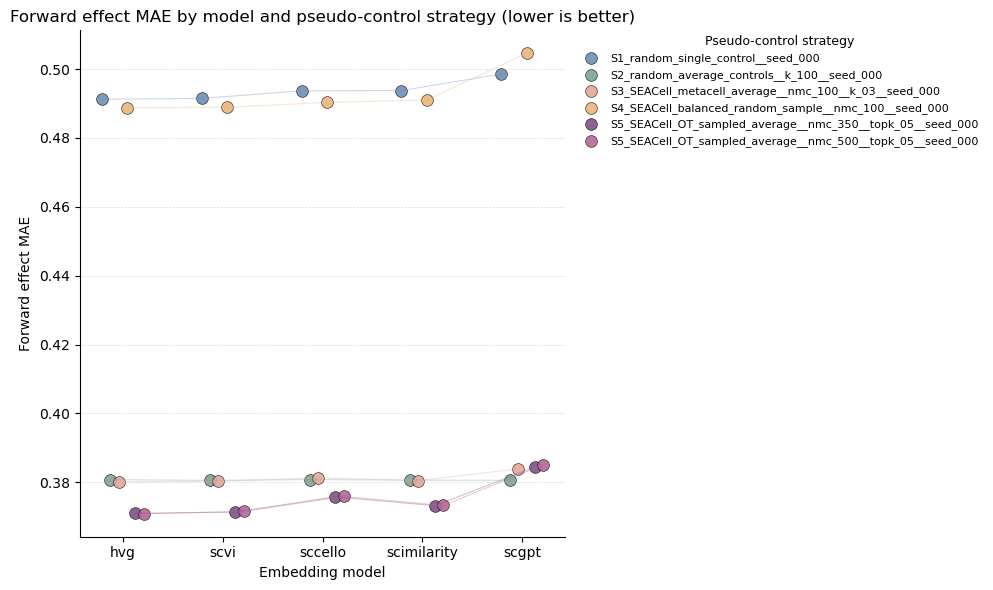

[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/forward_effect_mae_strategy_scatter.png
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/forward_effect_mae_strategy_scatter.pdf
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/forward_effect_mae_strategy_scatter.svg


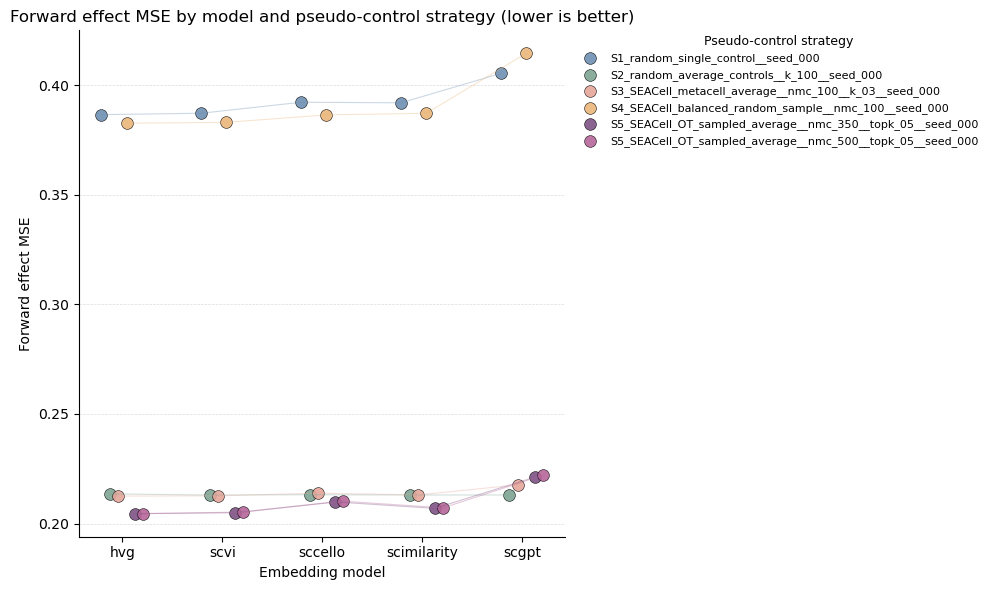

[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/forward_effect_mse_strategy_scatter.png
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/forward_effect_mse_strategy_scatter.pdf
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/forward_effect_mse_strategy_scatter.svg


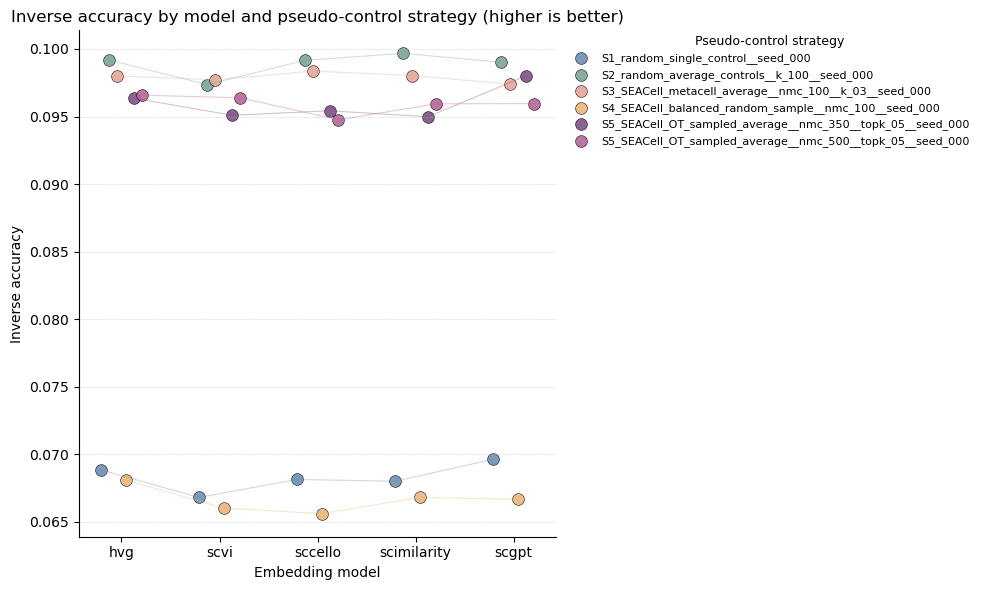

[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_accuracy_strategy_scatter.png
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_accuracy_strategy_scatter.pdf
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_accuracy_strategy_scatter.svg


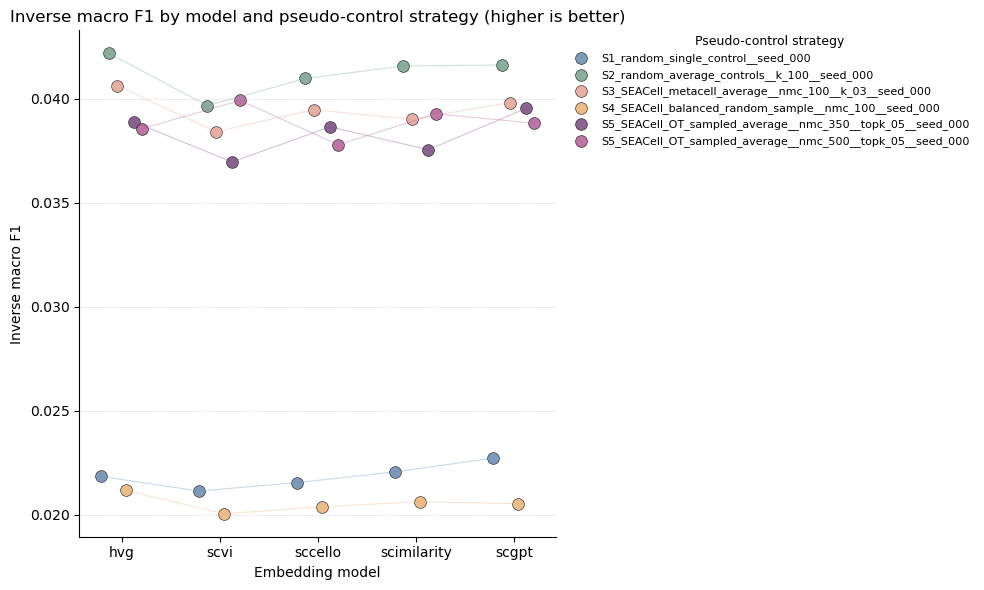

[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_f1_strategy_scatter.png
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_f1_strategy_scatter.pdf
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_f1_strategy_scatter.svg


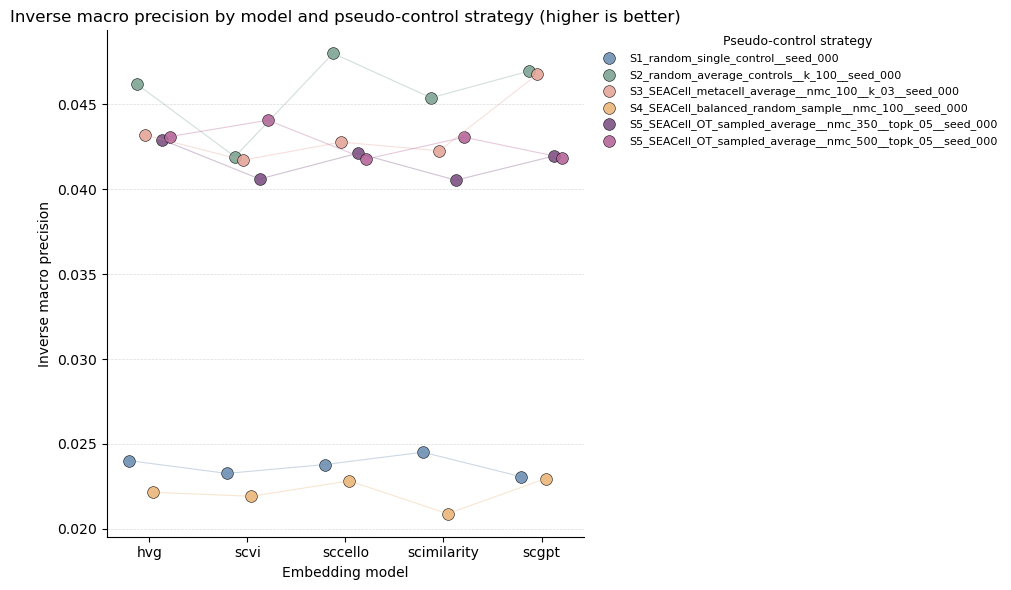

[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_precision_strategy_scatter.png
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_precision_strategy_scatter.pdf
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_precision_strategy_scatter.svg


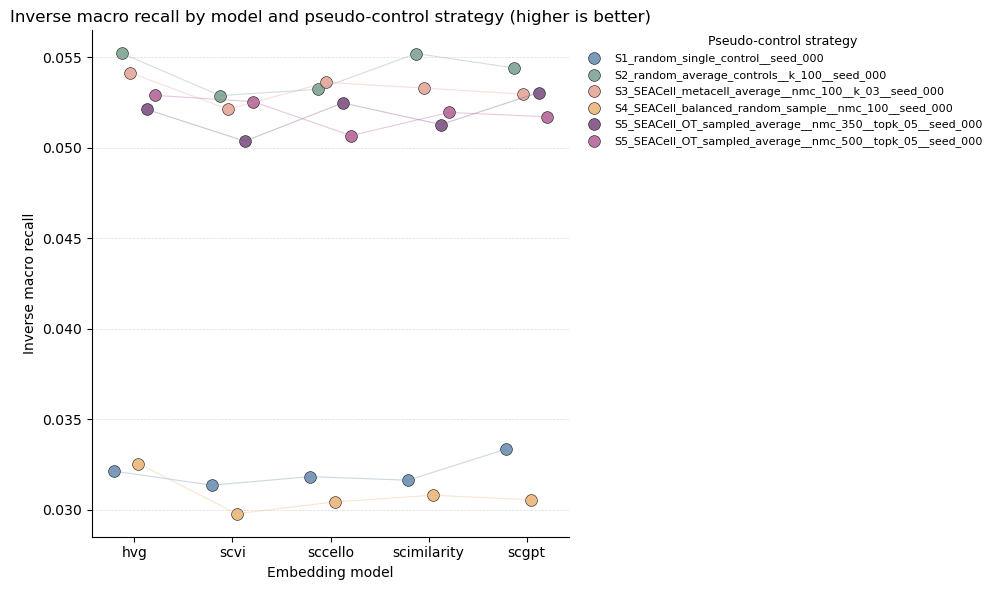

[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_recall_strategy_scatter.png
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_recall_strategy_scatter.pdf
[Plot] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_recall_strategy_scatter.svg


['/ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/forward_effect_mae_strategy_scatter.png',
 '/ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/forward_effect_mse_strategy_scatter.png',
 '/ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_accuracy_strategy_scatter.png',
 '/ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_f1_strategy_scatter.png',
 '/ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/inverse_macro_precision_strategy_scatter.png',
 '/ibex/user/chenj0

In [ ]:
saved_plots = []
for metric in METRICS_TO_PLOT:
    p = plot_metric_scatter(plot_df, metric, OUT_DIR)
    if p is not None:
        saved_plots.append(str(p))

saved_plots

In [ ]:
def summarize_best_strategy(df: pd.DataFrame, metrics: List[str]) -> pd.DataFrame:
    rows = []
    for metric in metrics:
        if metric not in df.columns:
            continue

        lower = LOWER_IS_BETTER.get(metric, False)
        for model in MODELS_ORDER:
            sub = df[df["model"].astype(str).eq(model)].dropna(subset=[metric]).copy()
            if sub.empty:
                continue

            if lower:
                best = sub.loc[sub[metric].idxmin()]
            else:
                best = sub.loc[sub[metric].idxmax()]

            rows.append({
                "metric": metric,
                "direction": "lower_is_better" if lower else "higher_is_better",
                "model": model,
                "best_variant_slug": str(best["variant_slug"]),
                "best_strategy_label": get_strategy_label(str(best["variant_slug"])),
                "best_value": float(best[metric]),
            })

    return pd.DataFrame(rows)


best_df = summarize_best_strategy(plot_df, METRICS_TO_PLOT)
best_path = OUT_DIR / "best_strategy_by_model_metric.csv"
best_df.to_csv(best_path, index=False)
print(f"[Best] Saved: {best_path}")
display(best_df)

[Best] Saved: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/best_strategy_by_model_metric.csv


,metric,direction,model,best_variant_slug,best_strategy_label,best_value
0,forward_effect_mae,lower_is_better,hvg,S5_SEACell_OT_sampled_average__nmc_500__topk_0...,Metacell OT\nsampled\naverage\n(500&5),0.370851
1,forward_effect_mae,lower_is_better,scvi,S5_SEACell_OT_sampled_average__nmc_350__topk_0...,Metacell OT\nsampled\naverage\n(350&5),0.371323
2,forward_effect_mae,lower_is_better,sccello,S5_SEACell_OT_sampled_average__nmc_350__topk_0...,Metacell OT\nsampled\naverage\n(350&5),0.375739
3,forward_effect_mae,lower_is_better,scimilarity,S5_SEACell_OT_sampled_average__nmc_350__topk_0...,Metacell OT\nsampled\naverage\n(350&5),0.373186
4,forward_effect_mae,lower_is_better,scgpt,S2_random_average_controls__k_100__seed_000,Random\naverage\ncontrol,0.380541
5,forward_effect_mse,lower_is_better,hvg,S5_SEACell_OT_sampled_average__nmc_350__topk_0...,Metacell OT\nsampled\naverage\n(350&5),0.204494
6,forward_effect_mse,lower_is_better,scvi,S5_SEACell_OT_sampled_average__nmc_350__topk_0...,Metacell OT\nsampled\naverage\n(350&5),0.204928
7,forward_effect_mse,lower_is_better,sccello,S5_SEACell_OT_sampled_average__nmc_350__topk_0...,Metacell OT\nsampled\naverage\n(350&5),0.209898
8,forward_effect_mse,lower_is_better,scimilarity,S5_SEACell_OT_sampled_average__nmc_350__topk_0...,Metacell OT\nsampled\naverage\n(350&5),0.206922
9,forward_effect_mse,lower_is_better,scgpt,S2_random_average_controls__k_100__seed_000,Random\naverage\ncontrol,0.213042


In [ ]:
print("Saved outputs:")
print(f"  Plotting table: {OUT_DIR / 'plotting_table.csv'}")
print(f"  Full scan:      {OUT_DIR / 'run_result_scan_all.csv'}")
print(f"  Best table:     {OUT_DIR / 'best_strategy_by_model_metric.csv'}")
print(f"  Figures:        {OUT_DIR}")

Saved outputs:
  Plotting table: /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/plotting_table.csv
  Full scan:      /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/run_result_scan_all.csv
  Best table:     /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots/best_strategy_by_model_metric.csv
  Figures:        /ibex/user/chenj0i/Perturbation/SEACells/Junfan_scripts/Tokenization_FMs/_embedding_mlp_forward_inverse_k562_smaller_mlp/metrics/_strategy_scatterplots
